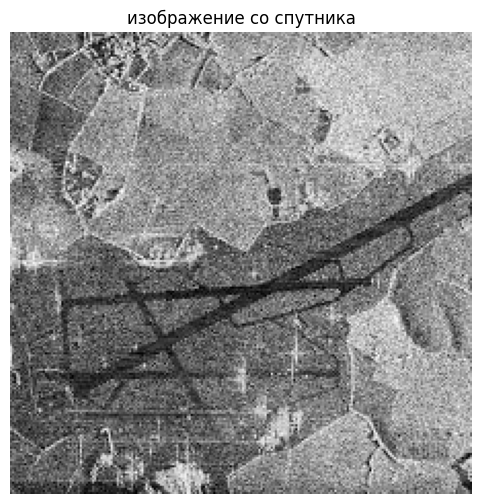

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy

# Загрузка изображения
image_path = 'sar_3.jpg'
image = cv2.imread(image_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap="gray")
plt.title("изображение со спутника")
plt.axis('off')
plt.show()

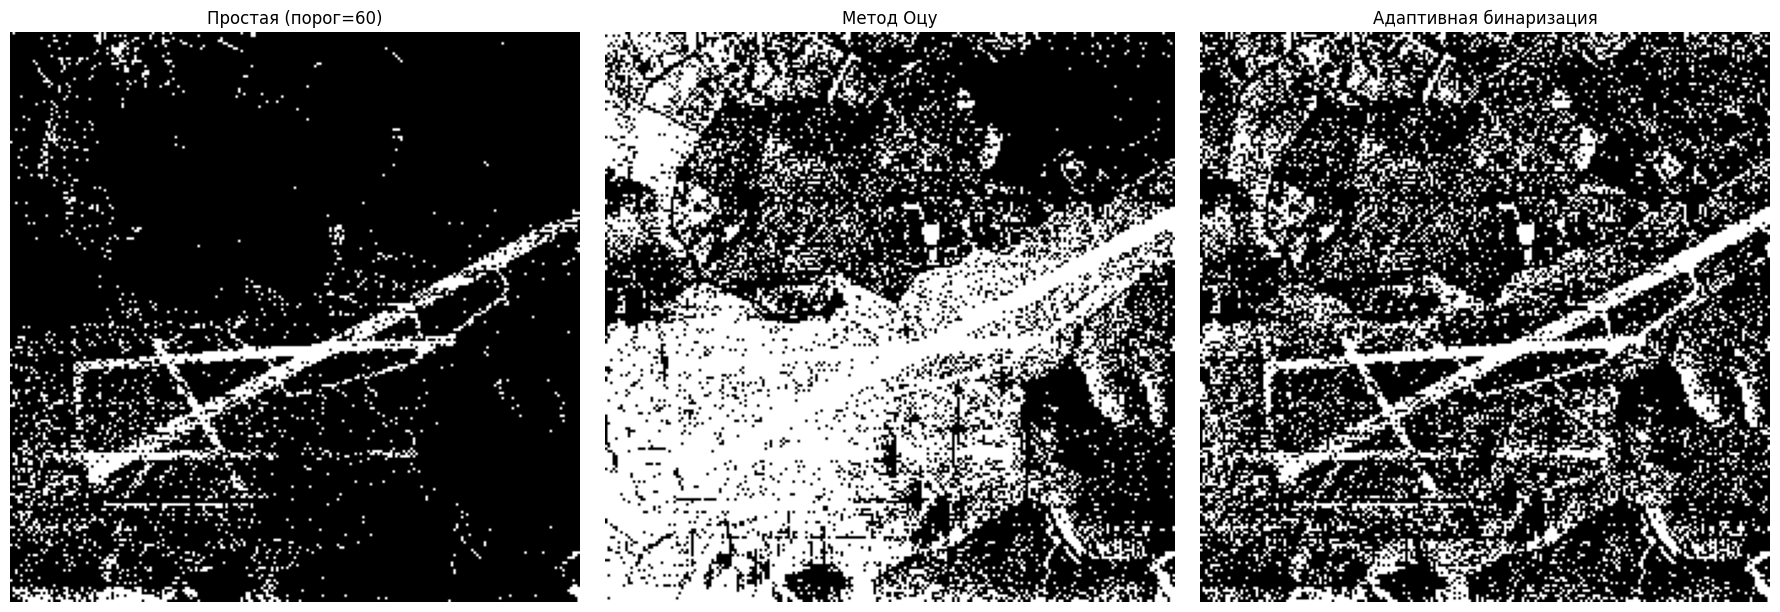

In [14]:
# 1 пороговая бинаризация (подбираем порог примерно, например 60)
# Инвертируем, чтобы темные дороги стали белыми
_, th1 = cv2.threshold(image_gray, 60, 255, cv2.THRESH_BINARY_INV)

# 2 Бинаризация Оцу (автоматический подбор порога)
_, th2 = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 3 Адаптивная бинаризация Гаусса (хорошо работает при неравномерном освещении)
th3 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY_INV, 71, 21)

# Вывод бинаризации
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(th1, cmap="gray")
axes[0].set_title("Простая (порог=60)")
axes[0].axis('off')

axes[1].imshow(th2, cmap="gray")
axes[1].set_title("Метод Оцу")
axes[1].axis('off')

axes[2].imshow(th3, cmap="gray")
axes[2].set_title("Адаптивная бинаризация")
axes[2].axis('off')

plt.tight_layout()
plt.show()

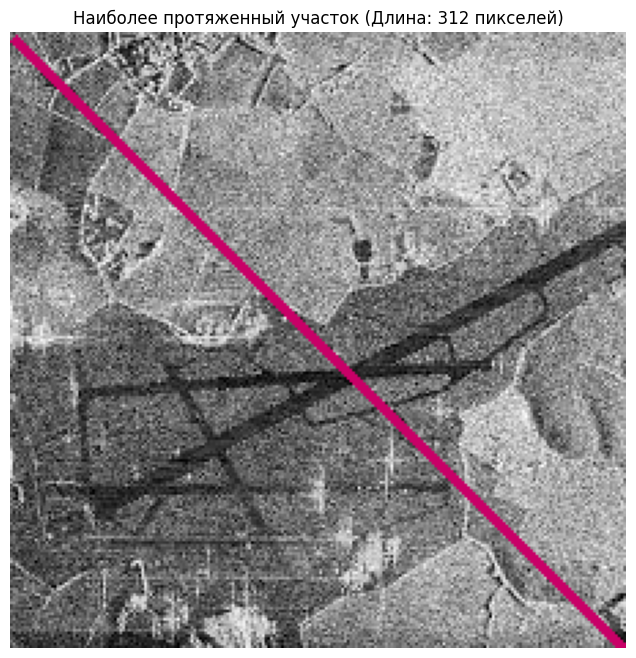

In [8]:
# 1 Поиск границ (алгоритм Canny)
edges = cv2.Canny(image_gray, 50, 150, apertureSize=3)

# 2 преобразование Хафа для поиска линий
# Параметры подбираются для выделения крупных структур
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=50, maxLineGap=10)

max_length = 0
longest_line = None

# 3 Ищем самую длинную линию среди найденных
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Вычисляем длину отрезка по теореме Пифагора
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        if length > max_length:
            max_length = length
            longest_line = line[0]

#  Отрисовка самой длинной линии
result_hough = image.copy()
if longest_line is not None:
    x1, y1, x2, y2 = longest_line
    # Рисуем красную толстую линию
    cv2.line(result_hough, (x1, y1), (x2, y2), (103, 0, 200), 3)

# Конвертируем BGR в RGB
result_hough_rgb = cv2.cvtColor(result_hough, cv2.COLOR_BGR2RGB)

# Вывод результата
plt.figure(figsize=(8, 8))
plt.imshow(result_hough_rgb)
plt.title(f"Наиболее протяженный участок (Длина: {int(max_length)} пикселей)")
plt.axis('off')
plt.show()

Длины найденных взлетно-посадочных полос (в пикселях):
Участок 1: 198 пикселей
Участок 2: 195 пикселей
Участок 3: 116 пикселей
Участок 4: 88 пикселей
Участок 5: 87 пикселей
Участок 6: 81 пикселей
Участок 7: 58 пикселей


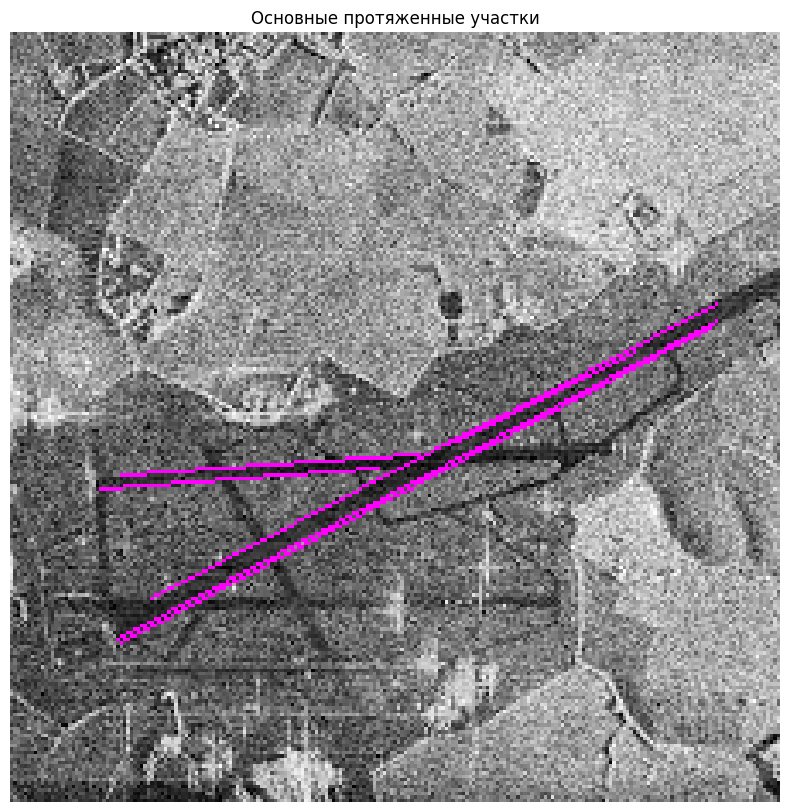

In [27]:

# Сглаживаем зернистый шум медианным фильтром
blur = cv2.medianBlur(image_gray, 5)
# Применяем бинаризацию (чтобы дороги стали четкими)
_, thresh = cv2.threshold(blur, 60, 255, cv2.THRESH_BINARY_INV)

# 2. Поиск границ
edges = cv2.Canny(thresh, 50, 150)

# 3 преобразование Хафа
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=40, minLineLength=50, maxLineGap=20)

all_lines = []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Вычисляем длину
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        all_lines.append((line[0], length))

# Сортируем от самой длинной к самой короткой
all_lines.sort(key=lambda x: x[1], reverse=True)

# Отрисовка
result_hough = image.copy()
print("Длины найденных полос(в пикселях):")

# Берем 6 самых длинных линий
for i, (line, length) in enumerate(all_lines[:6]):
    x1, y1, x2, y2 = line
    print(f"Участок {i+1}: {int(length)} пикселей")
    # Рисуем
    cv2.line(result_hough, (x1, y1), (x2, y2), (255, 0, 255), 1)

# Вывод результата
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(result_hough, cv2.COLOR_BGR2RGB))
plt.title("Основные протяженные участки")
plt.axis('off')
plt.show()